# Pandas

:::{dropdown} YouTube Video
:::{iframe} https://www.youtube.com/embed/rI27Xm_ny10
:width: 100%
Video not loading? Click [here](https://www.youtube.com/watch?v=rI27Xm_ny10).
:::

:::{note}
This material is mostly adapted from the following resources:
- [Earth and Environmental Data Science: Pandas](https://earth-env-data-science.github.io/lectures/pandas/pandas_intro.html)
- [Python Programming for Data Science: Pandas](https://www.tomasbeuzen.com/python-programming-for-data-science/chapters/chapter7-pandas.html)
:::

<img src="https://pandas.pydata.org/static/img/pandas.svg" width="300px" />

[Pandas](http://pandas.pydata.org/) is a an open source library providing Excel-like tables in Python.
It offers functionality for efficiently reading, writing, and processing data such as sorting, filtering, aggregating, and visualizing. Moreover, it provides tools for handling missing data and time series data.

<img src="https://media.geeksforgeeks.org/wp-content/cdn-uploads/creating_dataframe1.png" width="720px" />

:::{note}
Documentation for this package is available at https://pandas.pydata.org/docs/.
:::

:::{note}
If you have not yet set up Python on your computer, you can execute this tutorial in your browser via [Google Colab](https://colab.research.google.com/). Download the `.ipynb` file using the download button on the top right corner and import it in [Google Colab](https://colab.research.google.com/).

Then install `pandas` and `numpy` by executing the following command in a Jupyter cell at the top of the notebook.

```sh
!pip install pandas numpy
```
:::

In [73]:
import pandas as pd
import numpy as np

## The `Series`

A Series represents a one-dimensional array of data. The main difference between a Series and numpy array is that a Series has an **index**. The index contains the labels that we use to access the data. It is actually quite similar to a Python dictionary, where each value is associated with a key.

There are many ways to [create a Series](https://pandas.pydata.org/pandas-docs/stable/dsintro.html#series), but the core constructor is [`pd.Series()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.html) which can process a dictionary to create a Series.

:::{note}
The data used below is from Wikipedia's [List of power stations in Germany](https://en.wikipedia.org/wiki/List_of_power_stations_in_Germany#Nuclear).
:::

In [74]:
dictionary = {
    "Neckarwestheim": 1269,
    "Isar 2": 1365,
    "Emsland": 1290,
}
s = pd.Series(dictionary)
s

Neckarwestheim    1269
Isar 2            1365
Emsland           1290
dtype: int64

In [75]:
dictionary

{'Neckarwestheim': 1269, 'Isar 2': 1365, 'Emsland': 1290}

Arithmetic operations and most `numpy` functions can be applied to `pd.Series`.
An important point is that the Series keep their index during such operations.

In [76]:
np.log(s) / s**0.5

Neckarwestheim    0.200600
Isar 2            0.195391
Emsland           0.199418
dtype: float64

We can access the underlying index object if we need to:

In [77]:
s.index

Index(['Neckarwestheim', 'Isar 2', 'Emsland'], dtype='object')

We can get values back out using the index via the `.loc` attribute

In [78]:
s.loc["Isar 2"]

np.int64(1365)

Or by raw position using `.iloc`

In [79]:
s.iloc[2]

np.int64(1290)

We can pass a list or array to loc to get multiple rows back:

In [80]:
s.loc[["Neckarwestheim", "Emsland"]]

Neckarwestheim    1269
Emsland           1290
dtype: int64

And we can even use so-called *slicing* notation (`:`) to get ranges of rows:

In [81]:
s.loc["Neckarwestheim":"Emsland"]

Neckarwestheim    1269
Isar 2            1365
Emsland           1290
dtype: int64

In [82]:
s.iloc[:2]

Neckarwestheim    1269
Isar 2            1365
dtype: int64

If we need to, we can always get the raw data back out as well

In [83]:
type(s.values)  # a numpy array

numpy.ndarray

## The `DataFrame`

There is a lot more to a `pandas.Series`, but they are limit to a single **column**. A more broadly useful Pandas data structure is the **DataFrame**. `pandas.DataFrame` is a collection of series that share the same index. It's a lot like a table in a spreadsheet.

The core constructor is `pd.DataFrame()`, which can be used like this using a dictionary of lists:

In [84]:
data = {
    "capacity": [1269, 1365, 1290],  # MW
    "type": ["PWR", "PWR", "PWR"],
    "start_year": [1989, 1988, 1988],
    "end_year": [np.nan, np.nan, np.nan],
}

In [85]:
df = pd.DataFrame(data, index=["Neckarwestheim", "Isar 2", "Emsland"])
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,NaN
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,NaN


We can also switch columns and rows very easily using the `.T` (transpose) attribute:

In [86]:
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,NaN
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,NaN


A wide range of statistical functions are available on both Series and DataFrames.

In [87]:
df.min()

capacity      1269
type           PWR
start_year    1988
end_year       NaN
dtype: object

In [88]:
df.mean(numeric_only=True)

capacity      1308.000000
start_year    1988.333333
end_year              NaN
dtype: float64

In [89]:
df.describe()

,capacity,start_year,end_year
count,3.000000,3.000000,0.0
mean,1308.000000,1988.333333,NaN
std,50.467812,0.577350,NaN
min,1269.000000,1988.000000,NaN
25%,1279.500000,1988.000000,NaN
50%,1290.000000,1988.000000,NaN
75%,1327.500000,1988.500000,NaN
max,1365.000000,1989.000000,NaN


We can get a single column as a Series using python's getitem syntax on the DataFrame object.

In [90]:
df["capacity"]

Neckarwestheim    1269
Isar 2            1365
Emsland           1290
Name: capacity, dtype: int64

...or using attribute syntax.

In [91]:
df.end_year

Neckarwestheim   NaN
Isar 2           NaN
Emsland          NaN
Name: end_year, dtype: float64

Indexing works very similar to series

In [92]:
df.loc["Emsland"]

capacity      1290
type           PWR
start_year    1988
end_year       NaN
Name: Emsland, dtype: object

In [93]:
df.iloc[2]

capacity      1290
type           PWR
start_year    1988
end_year       NaN
Name: Emsland, dtype: object

But we can also specify the column(s) and row(s) we want to access

In [94]:
df.loc["Emsland", "start_year"]

np.int64(1988)

In [95]:
df.loc[["Emsland", "Neckarwestheim"], ["start_year", "end_year"]]

,start_year,end_year
Emsland,1988,NaN
Neckarwestheim,1989,NaN


Mathematical operations work as well, either on the whole DataFrame or on specific columns, the result of which can be assigned to a new column:

In [96]:
df.capacity * 0.8

Neckarwestheim    1015.2
Isar 2            1092.0
Emsland           1032.0
Name: capacity, dtype: float64

In [97]:
df["reduced_capacity"] = df.capacity * 0.8
df

,capacity,type,start_year,end_year,reduced_capacity
Neckarwestheim,1269,PWR,1989,NaN,1015.2
Isar 2,1365,PWR,1988,NaN,1092.0
Emsland,1290,PWR,1988,NaN,1032.0


## Cleaning Data

We can also **remove** columns or rows from a DataFrame:

In [98]:
df.drop("reduced_capacity", axis="columns")
df

,capacity,type,start_year,end_year,reduced_capacity
Neckarwestheim,1269,PWR,1989,NaN,1015.2
Isar 2,1365,PWR,1988,NaN,1092.0
Emsland,1290,PWR,1988,NaN,1032.0


We can update the variable `df` by either overwriting `df` or passing an `inplace` keyword:

In [99]:
df = df.drop("reduced_capacity", axis="columns")

In [100]:
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,NaN
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,NaN


We can also **drop columns** with only NaN values

In [101]:
df.dropna(axis=1, how="any")

,capacity,type,start_year
Neckarwestheim,1269,PWR,1989
Isar 2,1365,PWR,1988
Emsland,1290,PWR,1988


Or fill it up with default **fallback** data:

In [102]:
df.fillna(2023)
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,NaN
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,NaN


Say, we already have one value for `end_year` and want to fill up the **missing data**. We can use forward fill (`ffill`) or backward fill (`bfill`):

In [103]:
df.loc["Emsland", "end_year"] = 2023
df.loc["Neckarwestheim", "end_year"] = 2026
df

,capacity,type,start_year,end_year
Neckarwestheim,1269,PWR,1989,2026.0
Isar 2,1365,PWR,1988,NaN
Emsland,1290,PWR,1988,2023.0


In [104]:
df["end_year"] = df["end_year"].ffill()
df
df["x"] = np.nan
df["y"] = np.nan
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,NaN
Isar 2,1365,PWR,1988,2026.0,NaN,NaN
Emsland,1290,PWR,1988,2023.0,NaN,NaN


Sometimes it can be useful to **rename** columns:

In [105]:
df.rename(columns=dict(x="lat", y="lon"))

,capacity,type,start_year,end_year,lat,lon
Neckarwestheim,1269,PWR,1989,2026.0,NaN,NaN
Isar 2,1365,PWR,1988,2026.0,NaN,NaN
Emsland,1290,PWR,1988,2023.0,NaN,NaN


Sometimes it can be useful to **replace** values:

In [106]:
df.replace({"PWR": "Pressurized water reactor"})

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,Pressurized water reactor,1989,2026.0,NaN,NaN
Isar 2,1365,Pressurized water reactor,1988,2026.0,NaN,NaN
Emsland,1290,Pressurized water reactor,1988,2023.0,NaN,NaN


In [107]:
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,NaN
Isar 2,1365,PWR,1988,2026.0,NaN,NaN
Emsland,1290,PWR,1988,2023.0,NaN,NaN


In many cases, we want to **modify** values in a dataframe based on some rule. To modify values, we need to use `.loc` or `.iloc`. It can be use to set a specific value or a set of values based on their index and column labels:

In [108]:
df.loc["Isar 2", "start_year"] = 2000
df.loc["Emsland", "capacity"] += 10
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,NaN
Isar 2,1365,PWR,2000,2026.0,NaN,NaN
Emsland,1300,PWR,1988,2023.0,NaN,NaN


It can even be a completely new column:

In [109]:
operational = ["Neckarwestheim", "Isar 2", "Emsland"]
df.loc[operational, "y"] = [49.04, 48.61, 52.47]
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Emsland,1300,PWR,1988,2023.0,NaN,52.47


## Combining Datasets

Pandas supports a wide range of methods for merging different datasets. These are described extensively in the [documentation](https://pandas.pydata.org/pandas-docs/stable/merging.html). Here we just give a few examples.

In [110]:
data = {
    "capacity": [1288, 1360, 1326],  # MW
    "type": ["BWR", "PWR", "PWR"],
    "start_year": [1985, 1985, 1986],
    "end_year": [2021, 2021, 2021],
    "x": [10.40, 9.41, 9.35],
    "y": [48.51, 52.03, 53.85],
}
df2 = pd.DataFrame(data, index=["Gundremmingen", "Grohnde", "Brokdorf"])
df2

,capacity,type,start_year,end_year,x,y
Gundremmingen,1288,BWR,1985,2021,10.40,48.51
Grohnde,1360,PWR,1985,2021,9.41,52.03
Brokdorf,1326,PWR,1986,2021,9.35,53.85


We can now add this additional data to the `df` object

In [111]:
df = pd.concat([df, df2])
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Emsland,1300,PWR,1988,2023.0,NaN,52.47
Gundremmingen,1288,BWR,1985,2021.0,10.40,48.51
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85


## Sorting & Filtering Data

We can also **sort** the entries in dataframes, e.g. alphabetically by index or numerically by column values

In [112]:
df.sort_index()

,capacity,type,start_year,end_year,x,y
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85
Emsland,1300,PWR,1988,2023.0,NaN,52.47
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Gundremmingen,1288,BWR,1985,2021.0,10.40,48.51
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04


In [113]:
df.sort_values(by="end_year", ascending=False)

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Emsland,1300,PWR,1988,2023.0,NaN,52.47
Gundremmingen,1288,BWR,1985,2021.0,10.40,48.51
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85


We can also **filter** a DataFrame using a boolean series obtained from a condition. This is very useful to build subsets of the DataFrame.

In [114]:
df.capacity > 1300

Neckarwestheim    False
Isar 2             True
Emsland           False
Gundremmingen     False
Grohnde            True
Brokdorf           True
Name: capacity, dtype: bool

In [115]:
df[df.capacity > 1300]

,capacity,type,start_year,end_year,x,y
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85


We can also combine multiple conditions, but we need to wrap the conditions with brackets!

In [116]:
df[(df.capacity > 1300) & (df.start_year >= 1988)]

,capacity,type,start_year,end_year,x,y
Isar 2,1365,PWR,2000,2026.0,NaN,48.61


Or we make [SQL-like](https://en.wikipedia.org/wiki/SQL) queries:

In [117]:
df.query("start_year == 1988")

,capacity,type,start_year,end_year,x,y
Emsland,1300,PWR,1988,2023.0,NaN,52.47


In [118]:
threshold = 1300
df.query("start_year == 1988 and capacity > @threshold")

,capacity,type,start_year,end_year,x,y


In [119]:
df

,capacity,type,start_year,end_year,x,y
Neckarwestheim,1269,PWR,1989,2026.0,NaN,49.04
Isar 2,1365,PWR,2000,2026.0,NaN,48.61
Emsland,1300,PWR,1988,2023.0,NaN,52.47
Gundremmingen,1288,BWR,1985,2021.0,10.40,48.51
Grohnde,1360,PWR,1985,2021.0,9.41,52.03
Brokdorf,1326,PWR,1986,2021.0,9.35,53.85


## Applying Functions

Sometimes it can be useful to **apply** a function to all values of a column/row. For instance, we might be interested in normalised capacities relative to the largest nuclear power plant:

In [120]:
def normalise(s):
    return s / df.capacity.max()


df.capacity.apply(normalise)

Neckarwestheim    0.929670
Isar 2            1.000000
Emsland           0.952381
Gundremmingen     0.943590
Grohnde           0.996337
Brokdorf          0.971429
Name: capacity, dtype: float64

For simple functions, there's often an easier alternative:

In [121]:
def normalise(s: float):
    # adsfjielfwa
    return s / df.capacity.max()


df.capacity.apply(normalise)

Neckarwestheim    0.929670
Isar 2            1.000000
Emsland           0.952381
Gundremmingen     0.943590
Grohnde           0.996337
Brokdorf          0.971429
Name: capacity, dtype: float64

But the `.apply()` function often gives you more flexibility.

## Plotting

DataFrames have all kinds of [useful plotting](https://pandas.pydata.org/pandas-docs/stable/visualization.html) built in.

:::{note}
Note, that we do not even have to import `matplotlib` for this. It is used under the hood by `pandas` to create the plots.
:::

<Axes: xlabel='start_year', ylabel='capacity'>

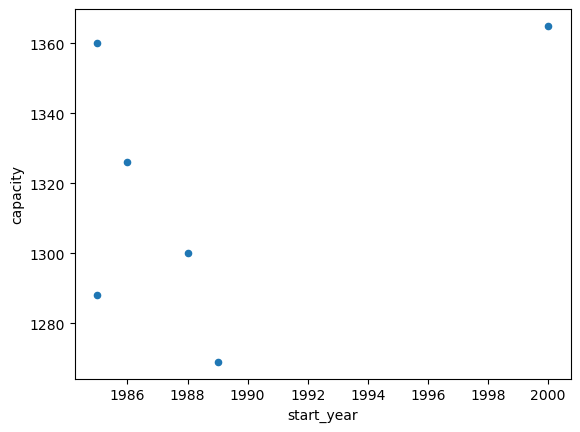

In [122]:
df.plot(kind="scatter", x="start_year", y="capacity")

Text(0.5, 0, 'Capacity (MW)')

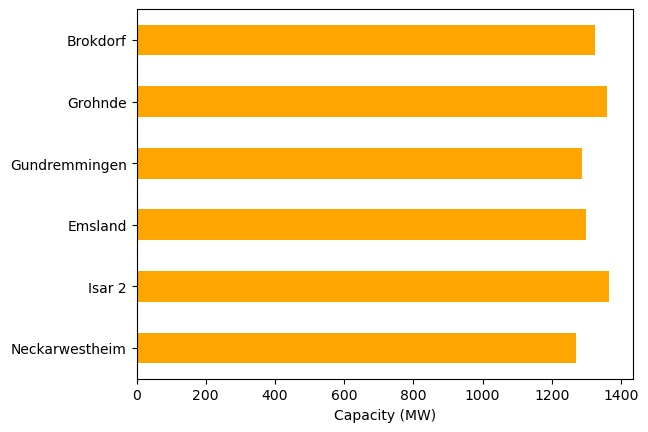

In [123]:
df.capacity.plot.barh(color="orange")
import matplotlib.pyplot as plt

plt.xlabel("Capacity (MW)")

## Time Indexes

Indexes are very powerful. They are a big part of why Pandas is so useful. There are different indices for different types of data. Time Indexes are especially great when handling time-dependent data.

In [124]:
time = pd.date_range(start="2021-01-01", end="2023-01-01", freq="D")
time.dayofyear

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       357, 358, 359, 360, 361, 362, 363, 364, 365,   1],
      dtype='int32', length=731)

In [125]:
values = np.sin(2 * np.pi * time.dayofyear / 365)
values

Index([ 0.017213356155834685,   0.03442161162274574,  0.051619667223253764,
         0.06880242680231986,   0.08596479873744647,   0.10310169744743485,
          0.1202080448993527,   0.13727877211326478,   0.15430882066428117,
          0.1712931441814776,
       ...
        -0.13727877211326517,  -0.12020804489935275,  -0.10310169744743544,
         -0.0859647987374467,  -0.06880242680232064,  -0.05161966722325418,
       -0.034421611622745804,  -0.01721335615583528, 6.432490598706546e-16,
        0.017213356155834685],
      dtype='float64', length=731)

In [126]:
values = np.sin(2 * np.pi * time.dayofyear / 365)
ts = pd.Series(values, index=time)
ts

2021-01-01    1.721336e-02
2021-01-02    3.442161e-02
2021-01-03    5.161967e-02
2021-01-04    6.880243e-02
2021-01-05    8.596480e-02
                  ...     
2022-12-28   -5.161967e-02
2022-12-29   -3.442161e-02
2022-12-30   -1.721336e-02
2022-12-31    6.432491e-16
2023-01-01    1.721336e-02
Freq: D, Length: 731, dtype: float64

<Axes: >

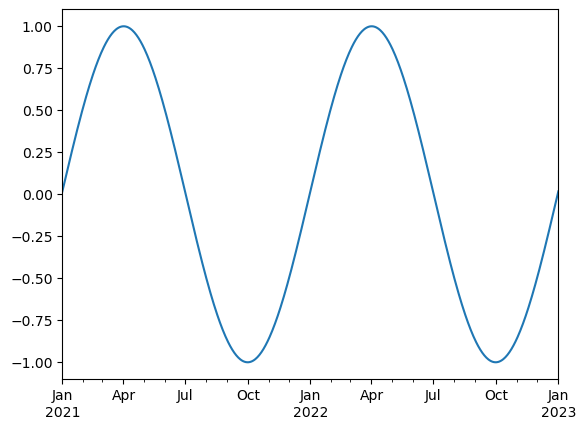

In [127]:
ts.plot()

We can use Python's _slicing_ notation inside `.loc` to select a date range.

<Axes: >

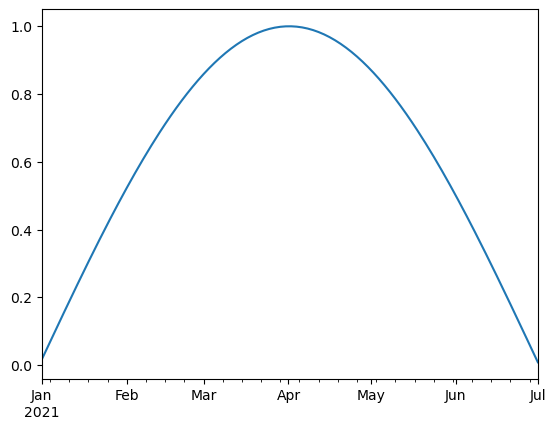

In [128]:
ts.loc["2021-01-01":"2021-07-01"].plot()

<Axes: >

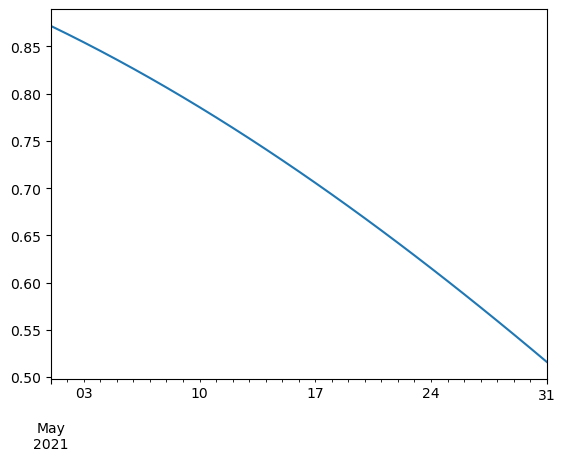

In [129]:
ts.loc["2021-05"].plot()

The `pd.TimeIndex` object has lots of useful attributes

In [130]:
ts.index.month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12,  1],
      dtype='int32', length=731)

In [131]:
ts.index.weekday

Index([4, 5, 6, 0, 1, 2, 3, 4, 5, 6,
       ...
       4, 5, 6, 0, 1, 2, 3, 4, 5, 6],
      dtype='int32', length=731)

Another common operation is to **change the resolution** of a dataset by resampling in time. Pandas exposes this through the `.resample()` function. The resample periods are specified using pandas [offset index](http://pandas.pydata.org/pandas-docs/stable/timeseries.html#offset-aliases) syntax.

Below, we **resample** the dataset by taking the mean over each month.

In [132]:
ts.resample("12h").mean().interpolate()

2021-01-01 00:00:00    1.721336e-02
2021-01-01 12:00:00    2.581748e-02
2021-01-02 00:00:00    3.442161e-02
2021-01-02 12:00:00    4.302064e-02
2021-01-03 00:00:00    5.161967e-02
                           ...     
2022-12-30 00:00:00   -1.721336e-02
2022-12-30 12:00:00   -8.606678e-03
2022-12-31 00:00:00    6.432491e-16
2022-12-31 12:00:00    8.606678e-03
2023-01-01 00:00:00    1.721336e-02
Freq: 12h, Length: 1461, dtype: float64

<Axes: >

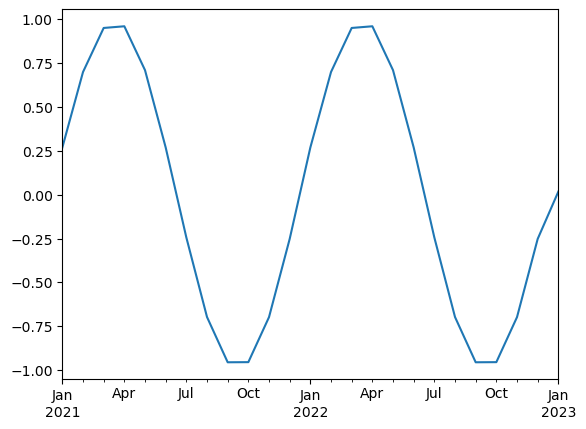

In [133]:
ts.resample("ME").mean().plot()

## Reading and Writing Files

To **read** data into pandas, we can use for instance the [`pd.read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) function. This function is quite powerful and complex with many different settings. You can use it to extract data from almost any text file.

The `pd.read_csv()` function can take a path to a local file as an input, or even a hyperlink to an online text file.

Let's import a slightly larger dataset about the power plant fleet in Europe_

In [147]:
#fn = "https://raw.githubusercontent.com/PyPSA/powerplantmatching/master/powerplants.csv"
fn = "powerplants.csv"

In [148]:
df = pd.read_csv(fn, index_col=0)

In [149]:
df = pd.read_csv(fn, index_col=0)
df.iloc[:5, :10]

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut
id,,,,,,,,,,
0,Pumpspeicherkraftwerk Erzhausen,Hydro,Pumped Storage,Storage,Germany,200.0,0.75,1964.0,1998.0,NaN
1,La Plate Taille,Hydro,Pumped Storage,Store,Belgium,144.0,NaN,1970.0,NaN,NaN
2,Illwerke Vkw Rodundwerk,Hydro,Reservoir,Store,Austria,495.0,0.75,1943.0,2011.0,NaN
3,Bissorte,Hydro,Pumped Storage,Store,France,818.0,NaN,1936.0,NaN,NaN
4,Obervermuntwerk Maschine Turbine,Hydro,Pumped Storage,Storage,Austria,380.0,0.75,1943.0,2018.0,NaN


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165064 entries, 0 to 165578
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Name                 165064 non-null  object 
 1   Fueltype             165064 non-null  object 
 2   Technology           112729 non-null  object 
 3   Set                  164686 non-null  object 
 4   Country              165064 non-null  object 
 5   Capacity             165030 non-null  float64
 6   Efficiency           510 non-null     float64
 7   DateIn               160380 non-null  float64
 8   DateRetrofit         2553 non-null    float64
 9   DateOut              4720 non-null    float64
 10  lat                  165064 non-null  float64
 11  lon                  165064 non-null  float64
 12  Duration             1854 non-null    float64
 13  Volume_Mm3           1762 non-null    float64
 14  DamHeight_m          2010 non-null    float64
 15  StorageCapacity_MWh  2

In [151]:
df.describe()

,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh
count,165030.000000,510.000000,160380.000000,2553.000000,4720.000000,165064.000000,165064.000000,1854.000000,1762.000000,2010.000000,2.403000e+03
mean,9.200937,0.491218,2012.729979,1986.929886,2021.663983,50.724090,10.022293,467.960286,218.831859,188.197532,2.797997e+04
std,77.017392,0.176591,12.331854,25.376000,5.554505,3.321146,4.526664,1142.678665,1080.085642,255.058396,1.775409e+05
min,0.010000,0.191434,1898.000000,1899.000000,1969.000000,32.647300,-51.721900,0.000005,0.001600,-99.000000,1.000000e-05
25%,0.201280,0.363954,2010.000000,1969.000000,2021.000000,49.098707,8.114602,1.280000,4.250000,34.000000,7.080000e-01
50%,0.550000,0.399300,2014.000000,1994.000000,2022.000000,51.235462,9.899394,2.089000,23.400000,94.600000,9.380000e+00
75%,2.300000,0.588824,2020.000000,2008.000000,2024.000000,52.615489,12.067437,217.250987,112.150000,253.025000,1.147000e+03
max,5400.000000,0.917460,2040.000000,2020.000000,2050.000000,71.012300,39.655350,16840.000000,25810.000000,3051.460000,4.869834e+06


Sometimes, we also want to **store** a DataFrame for later use. There are many different file formats tabular data can be stored in,  including HTML, JSON, Excel, Parquet, Feather, etc. Here, let's say we want to store the DataFrame as CSV (comma-separated values) file under the name "tmp.csv".

In [152]:
df.to_csv("tmp.csv")

In [153]:
df

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
0,Pumpspeicherkraftwerk Erzhausen,Hydro,Pumped Storage,Storage,Germany,200.0,0.75,1964.0,1998.0,NaN,51.898566,9.924887,5.510000,1.600000,287.0,1102.000000,{nan},"{'MASTR': {'MASTR-SEE915985628661'}, 'GEM': {'..."
1,La Plate Taille,Hydro,Pumped Storage,Store,Belgium,144.0,NaN,1970.0,NaN,NaN,50.188400,4.386200,4.930556,68.400000,70.0,710.000000,{nan},"{'GEM': {'G100000600151'}, 'JRC': {'JRC-H347'}..."
2,Illwerke Vkw Rodundwerk,Hydro,Reservoir,Store,Austria,495.0,0.75,1943.0,2011.0,NaN,47.085032,9.880116,588.383838,2.240000,353.0,291250.000000,"{nan, nan, nan, nan, nan}","{'MASTR': {'MASTR-SEE952262880046', 'MASTR-SEE..."
3,Bissorte,Hydro,Pumped Storage,Store,France,818.0,NaN,1936.0,NaN,NaN,45.203600,6.581450,3.818182,39.500000,1160.0,3150.000000,"{nan, nan}","{'GEM': {'G100001052026', 'G100000601707'}, 'J..."
4,Obervermuntwerk Maschine Turbine,Hydro,Pumped Storage,Storage,Austria,380.0,0.75,1943.0,2018.0,NaN,46.935290,10.059950,71.573684,35.630769,291.0,27198.000000,"{nan, nan}","{'MASTR': {'MASTR-SEE926367113644', 'MASTR-SEE..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165574,Stramentizzo San Floriano,Hydro,Reservoir,Store,Italy,71.3,NaN,NaN,NaN,NaN,46.290466,11.245401,218.720806,11.500000,572.0,15594.793500,{nan},{'JRC': {'JRC-H3737'}}
165575,Taloro Deg Salto Benzone,Hydro,Reservoir,Store,Italy,32.7,NaN,NaN,NaN,NaN,40.127148,9.140644,272.313988,20.190000,241.0,8904.667391,"{nan, nan}","{'JRC': {'JRC-H3692', 'JRC-H3681'}}"
165576,Valina Ca Zul,Hydro,Reservoir,Store,Italy,8.0,NaN,NaN,NaN,NaN,46.294781,12.711214,325.978125,11.000000,100.0,2607.825000,{nan},{'JRC': {'JRC-H3738'}}


## Grouping and Aggregation

Both `Series` and `DataFrame` objects have a `groupby` method, which allows you to **group and aggregate** the data based on the values of one or more columns.

It accepts a variety of arguments, but the simplest way to think about it is that you pass another series, whose unique values are used to split the original object into different groups.

Here's an example which retrieves the total generation capacity per country.

In [154]:
grouped = df.groupby("Country").Capacity.sum()
grouped.sort_values(ascending=False).head(10)

Country
Germany           327104.098047
United Kingdom    164205.240000
France            155668.972001
Spain             147409.114800
Italy             105597.438000
Poland             67791.266738
Ukraine            57647.700000
Sweden             53198.022323
Netherlands        45319.900000
Norway             40555.110000
Name: Capacity, dtype: float64

Such **chaining** of multiple operations is very common with pandas.

Let's break apart this operation a bit. The workflow with `groupby` can be divided into three general steps:

1. **Split**: Partition the data into different groups based on some criterion.
1. **Apply**: Do some calculation (e.g. aggregation or transformation) within each group.
1. **Combine**: Put the results back together into a single object.

<img src="https://miro.medium.com/max/1840/1*JbF6nhrQsn4f-TaSF6IR9g.png" width="720px" />

Grouping is not only possible on a single columns, but also on multiple columns. For instance,
we might want to group the capacities by country **and** fuel type. To achieve this, we pass a list of functions to the `groupby` functions.

In [155]:
capacities = df.groupby(["Country", "Fueltype"]).Capacity.sum()
capacities

Country         Fueltype     
Albania         Hydro             2079.366
                Solar              454.200
                Wind               150.000
Austria         Battery             40.320
                Hard Coal         1471.000
                                   ...    
United Kingdom  Other               35.000
                Solar            13679.900
                Solid Biomass     4154.200
                Waste             1948.150
                Wind             39284.500
Name: Capacity, Length: 327, dtype: float64

By grouping by multiple attributes, our index becomes a `pd.MultiIndex` (a hierarchical index with multiple *levels*.

In [156]:
capacities.index[:5]

MultiIndex([('Albania',     'Hydro'),
            ('Albania',     'Solar'),
            ('Albania',      'Wind'),
            ('Austria',   'Battery'),
            ('Austria', 'Hard Coal')],
           names=['Country', 'Fueltype'])

In [157]:
type(capacities.index)

pandas.core.indexes.multi.MultiIndex

In [158]:
df.nsmallest(10, "Capacity")

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
25575,Balance,Hydrogen Storage,NaN,Store,Finland,0.01,NaN,NaN,NaN,NaN,64.000000,26.000000,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65017'}}
25651,Dresden,Hydrogen Storage,NaN,Store,Germany,0.01,NaN,NaN,NaN,NaN,51.050100,13.738300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65118'}}
25717,From The Sun Brunate,Hydrogen Storage,NaN,Store,Italy,0.01,NaN,NaN,NaN,NaN,45.823300,9.094200,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65064'}}
25718,Fronius Energy Cell Self Sufficient House,Hydrogen Storage,NaN,Store,Austria,0.01,NaN,NaN,NaN,NaN,48.208300,14.038300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65051'}}
25823,Laboratory System At Ife Kjeller Pahse,Hydrogen Storage,NaN,Store,Norway,0.01,NaN,NaN,NaN,NaN,60.223611,11.033333,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65033'}}
25928,Primolyzer,Hydrogen Storage,NaN,Store,Denmark,0.01,NaN,NaN,NaN,NaN,56.263900,9.501800,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65078'}}
25937,Rabh,Hydrogen Storage,NaN,Store,United Kingdom,0.01,NaN,NaN,NaN,NaN,50.719300,-1.880400,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65088'}}
25943,Regenerativer Energipark Ostfalia Hybrid Renew...,Hydrogen Storage,NaN,Store,Germany,0.01,NaN,NaN,NaN,NaN,52.323300,10.883300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65058'}}
25754,Hanau Wolfgang Industrial Park,Hydrogen Storage,NaN,Store,Germany,0.02,NaN,NaN,NaN,NaN,50.133300,8.933300,NaN,NaN,NaN,NaN,{nan},{'EESI': {'EESI-65039'}}


We can use the `.unstack` function to reshape the multi-indexed `pd.Series` into a `pd.DataFrame` which has the second index level as columns. 

In [159]:
capacities.unstack().fillna(0.0).T.round(1)

Country,Albania,Austria,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Czechia,Denmark,Estonia,Finland,...,Portugal,Romania,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Ukraine,United Kingdom
Fueltype,,,,,,,,,,,,,,,,,,,,,
Battery,0.0,40.3,191.2,0.0,219.6,1.0,0.0,52.1,35.5,214.2,...,58.1,261.9,0.0,5.3,62.6,119.0,543.5,68.0,1.0,6242.4
Biogas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,66.5
Geothermal,0.0,0.0,0.0,0.0,0.0,36.1,0.0,0.0,0.0,0.0,...,24.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,2.0
Hard Coal,0.0,1471.0,2865.0,0.0,2704.0,342.0,1548.0,5055.0,0.0,3787.2,...,2028.0,1705.0,0.0,989.0,124.0,11204.6,291.0,0.0,23628.0,35856.6
Heat Storage,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.2,0.0,625.2,...,0.0,0.0,0.0,0.0,0.0,1049.5,0.0,0.0,0.0,0.0
Hydro,2079.4,15571.8,1380.0,2264.0,2904.5,2118.9,1816.6,0.0,0.0,3143.1,...,9163.8,7562.4,3498.3,2470.1,1245.6,17794.4,14951.0,18083.1,6590.2,4769.6
Hydrogen Storage,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,1.3,...,1.0,0.0,0.0,0.0,0.0,2.9,0.0,0.0,0.0,2.2
Lignite,0.0,522.0,0.0,2090.0,6057.0,0.0,9380.1,0.0,0.0,150.0,...,0.0,6104.0,4817.0,548.0,1480.0,2729.0,0.0,0.0,0.0,0.0
Mechanical Storage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0


**In summary,** the typical workflow with pandas consists of reading data from files, inspecting and cleaning the data, performing analysis through transformation and aggregation, visualizing the results, and storing the processed data for later use.

## Exercises

### Power Plants Data

In this exercise, we will use the [powerplants.csv](https://raw.githubusercontent.com/PyPSA/powerplantmatching/master/powerplants.csv) dataset from the [powerplantmatching](https://github.com/PyPSA/powerplantmatching) project. This dataset contains information about various power plants, including their names, countries, fuel types, capacities, and more.

URL: `https://raw.githubusercontent.com/PyPSA/powerplantmatching/master/powerplants.csv`

**Task 1:** Load the dataset into a pandas DataFrame.

In [160]:
powerplants_df = pd.read_csv("powerplants.csv")

**Task 2:** Run the function `.describe()` on the DataFrame.

In [161]:
powerplants_df.describe()

,id,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh
count,165064.000000,165030.000000,510.000000,160380.000000,2553.000000,4720.000000,165064.000000,165064.000000,1854.000000,1762.000000,2010.000000,2.403000e+03
mean,82535.988677,9.200937,0.491218,2012.729979,1986.929886,2021.663983,50.724090,10.022293,467.960286,218.831859,188.197532,2.797997e+04
std,47651.354313,77.017392,0.176591,12.331854,25.376000,5.554505,3.321146,4.526664,1142.678665,1080.085642,255.058396,1.775409e+05
min,0.000000,0.010000,0.191434,1898.000000,1899.000000,1969.000000,32.647300,-51.721900,0.000005,0.001600,-99.000000,1.000000e-05
25%,41269.750000,0.201280,0.363954,2010.000000,1969.000000,2021.000000,49.098707,8.114602,1.280000,4.250000,34.000000,7.080000e-01
50%,82535.500000,0.550000,0.399300,2014.000000,1994.000000,2022.000000,51.235462,9.899394,2.089000,23.400000,94.600000,9.380000e+00
75%,123801.250000,2.300000,0.588824,2020.000000,2008.000000,2024.000000,52.615489,12.067437,217.250987,112.150000,253.025000,1.147000e+03
max,165578.000000,5400.000000,0.917460,2040.000000,2020.000000,2050.000000,71.012300,39.655350,16840.000000,25810.000000,3051.460000,4.869834e+06


**Task 3:** Provide a list of unique fuel types and technologies included in the dataset.

:::{note}
Look in the `pandas` documentation for functions that might be useful to solve these tasks.
:::

In [164]:
print(powerplants_df['Fueltype'].unique().tolist())
print(powerplants_df['Technology'].unique().tolist())

['Hydro', 'Hard Coal', 'Natural Gas', 'Lignite', 'Oil', 'Wind', 'Solid Biomass', 'Waste', 'Solar', 'Geothermal', 'Battery', 'Heat Storage', 'Nuclear', 'Other', 'Biogas', 'Mechanical Storage', 'Hydrogen Storage']
['Pumped Storage', 'Reservoir', 'Run-Of-River', 'Steam Turbine', 'CCGT', 'Onshore', 'OCGT', nan, 'PV', 'Offshore', 'Li', 'Csp', 'Pb', 'NaS', 'NiCd', 'CSP', 'CAES', 'Molten Salt', 'V', 'NaNiCl', 'Combustion Engine']


**Task 4:** Filter the dataset by power plants with the fuel type "Hard Coal".

In [170]:
pp_coal = powerplants_df.loc[powerplants_df['Fueltype'] == 'Hard Coal']
pp_coal.head()

,id,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
191,191,Salmisaari Phase,Hard Coal,Steam Turbine,Store,Finland,177.0,NaN,1984.0,NaN,2025.0,60.165375,24.904517,NaN,NaN,NaN,1200.0,{nan},"{'GEM': {'G100000108748'}, 'EESI': {'EESI-6315..."
193,193,Aberthaw,Hard Coal,Steam Turbine,PP,United Kingdom,1725.0,NaN,1971.0,2008.0,2020.0,51.387312,-3.404664,NaN,NaN,NaN,NaN,"{nan, nan, nan}","{'GEM': {'G100000100010', 'G100000100009', 'G1..."
194,194,Ostroleka Phase,Hard Coal,Steam Turbine,CHP,Poland,681.1,NaN,1957.0,2000.0,2015.0,53.103611,21.612500,NaN,NaN,NaN,NaN,"{nan, nan, nan, nan}","{'GEM': {'G100000107700', 'G100000107699', 'G1..."
195,195,Kozienice,Hard Coal,Steam Turbine,PP,Poland,2919.0,NaN,1972.0,NaN,2048.0,51.582930,21.547790,NaN,NaN,NaN,NaN,"{nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","{'GEM': {'G100000105923', 'G100000105926', 'G1..."
196,196,Maasvlakte Uniper,Hard Coal,Steam Turbine,PP,Netherlands,2306.0,NaN,1975.0,NaN,2029.0,51.958734,4.027208,NaN,NaN,NaN,NaN,"{nan, nan, nan}","{'GEM': {'G100000106536', 'G100000106537', 'G1..."


**Task 5:** Identify the 5 largest coal power plants. In which countries are they located? When were they built?

In [194]:
pp_coal.sort_values(by="Capacity", ascending=False)[["Capacity", "Name", "Country", "DateIn"]].head()

,Capacity,Name,Country,DateIn
562,4206.0,Drax Timepoint,United Kingdom,1974.0
588,3332.0,Opole,Poland,1993.0
2514,2925.0,Kryvorizka,Ukraine,1963.0
195,2919.0,Kozienice,Poland,1972.0
2536,2640.0,Brindisi Sud,Italy,1991.0


**Task 6:** Identify the power plant with the longest name.

In [185]:
powerplants_df = df.sort_values(by='Name', key=lambda x: x.str.len(), ascending=False)
powerplants_df.iloc[0]

Name                   Sonnenkraftwerk Albert Pielhau Gmbh Co Kg Gese...
Fueltype                                                           Solar
Technology                                                           NaN
Set                                                                   PP
Country                                                          Germany
Capacity                                                           0.168
Efficiency                                                           NaN
DateIn                                                            2014.0
DateRetrofit                                                         NaN
DateOut                                                              NaN
lat                                                             51.16537
lon                                                             7.482275
Duration                                                             NaN
Volume_Mm3                                         

**Task 7:** Identify the 10 northernmost powerplants. What type of power plants are they?

In [196]:
powerplants_df.sort_values(by = "lat", ascending = False).loc[0:9]

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
0,Pumpspeicherkraftwerk Erzhausen,Hydro,Pumped Storage,Storage,Germany,200.0000,0.75,1964.0,1998.0,NaN,51.898566,9.924887,5.51,1.6,287.0,1102.0,{nan},"{'MASTR': {'MASTR-SEE915985628661'}, 'GEM': {'..."
56730,Dachanlage,Solar,NaN,PP,Germany,0.4026,NaN,2020.0,NaN,NaN,51.898496,8.626889,NaN,NaN,NaN,NaN,{nan},{'MASTR': {'MASTR-SEE936649565344'}}
42890,Bhkw Duben,Biogas,Combustion Engine,CHP,Germany,0.8000,NaN,2009.0,NaN,NaN,51.898484,13.801091,NaN,NaN,NaN,NaN,{nan},{'MASTR': {'MASTR-SEE993333666527'}}
164334,Zieko,Wind,Onshore,PP,Germany,1.3000,NaN,1999.0,NaN,NaN,51.898433,12.400439,NaN,NaN,NaN,NaN,{nan},{'MASTR': {'MASTR-SEE988681930734'}}
156491,Wp Atzendorf,Wind,Onshore,PP,Germany,2.0000,NaN,2005.0,NaN,NaN,51.898408,11.602272,NaN,NaN,NaN,NaN,{nan},{'MASTR': {'MASTR-SEE913695496327'}}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12155,Centrales Photovoltaiques Ps Solar Farm,Solar,PV,PP,France,3.5000,NaN,2021.0,NaN,NaN,44.755500,4.748600,NaN,NaN,NaN,NaN,{nan},{'GEM': {'G100000819183'}}
2734,Stanari,Lignite,Steam Turbine,PP,Bosnia and Herzegovina,300.0000,NaN,2016.0,NaN,NaN,44.753861,17.792444,NaN,NaN,NaN,NaN,{nan},"{'GEM': {'G100000109595'}, 'ENTSOE': {'36W-TE-..."
18032,Loriol Sur Drome Confidentiel Solar,Solar,PV,PP,France,6.6000,NaN,2023.0,NaN,NaN,44.751800,4.822300,NaN,NaN,NaN,NaN,"{nan, nan, nan}","{'GEM': {'G100001072265', 'G100001072266', 'G1..."


**Task 8:** What is the average start year of each fuel type? Sort the fuel types by their average start year in ascending order and round to the nearest integer.

In [197]:
powerplants_df.groupby("Fueltype").DateIn.mean().round(0).sort_values(ascending=True)

Fueltype
Hard Coal             1972.0
Hydro                 1973.0
Lignite               1978.0
Nuclear               1981.0
Other                 2000.0
Geothermal            2003.0
Oil                   2004.0
Waste                 2004.0
Solid Biomass         2007.0
Wind                  2011.0
Biogas                2012.0
Natural Gas           2012.0
Solar                 2017.0
Battery               2023.0
Heat Storage             NaN
Hydrogen Storage         NaN
Mechanical Storage       NaN
Name: DateIn, dtype: float64

### Wind and Solar Capacity Factors

In this exercise, we will work with a time series dataset containing hourly wind and solar capacity factors for Ireland, taken from [model.energy](https://model.energy).

**Task 1:** Use `pd.read_csv` to load the dataset from the following URL into a pandas DataFrame. Ensure that the time stamps are treated as `pd.DatetimeIndex`.

In [209]:
timeseries = pd.read_csv("timeseries.csv", index_col=0, parse_dates=True)
timeseries

,onwind,solar
2011-01-01 00:00:00,0.022,0.0
2011-01-01 01:00:00,0.030,0.0
2011-01-01 02:00:00,0.043,0.0
2011-01-01 03:00:00,0.050,0.0
2011-01-01 04:00:00,0.054,0.0
...,...,...
2011-12-31 19:00:00,0.814,0.0
2011-12-31 20:00:00,0.782,0.0
2011-12-31 21:00:00,0.849,0.0
2011-12-31 22:00:00,0.941,0.0


**Task 2:** Calculate the mean capacity factor for wind and solar over the entire time period.


In [211]:
timeseries.mean()

onwind    0.366898
solar     0.099274
dtype: float64


**Task 3:** Calculate the correlation between wind and solar capacity factors.

:::{note}
Go to the [pandas documentation](https://pandas.pydata.org/pandas-docs/stable/index.html) for functions that might be useful to solve these tasks.
:::

In [212]:
timeseries.corr()

,onwind,solar
onwind,1.000000,-0.096682
solar,-0.096682,1.000000


**Task 4:** Plot the wind and solar capacity factors for the month of May.

<Axes: ylabel='capacity factor'>

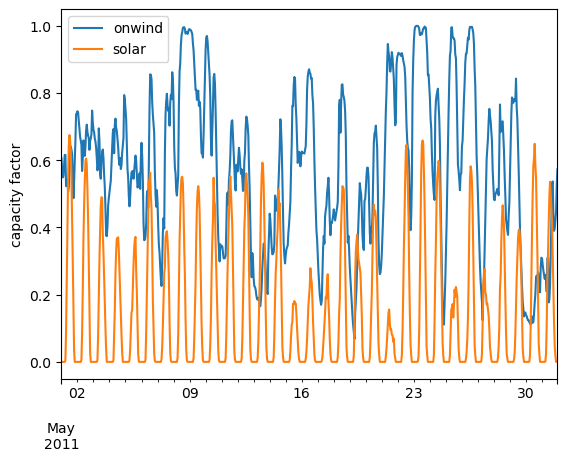

In [217]:
timeseries.loc["05-2011"].plot(ylabel="capacity factor")

**Task 5:** Plot the weekly average capacity factors for wind and solar over the entire time period.

<Axes: ylabel='capacity factor'>

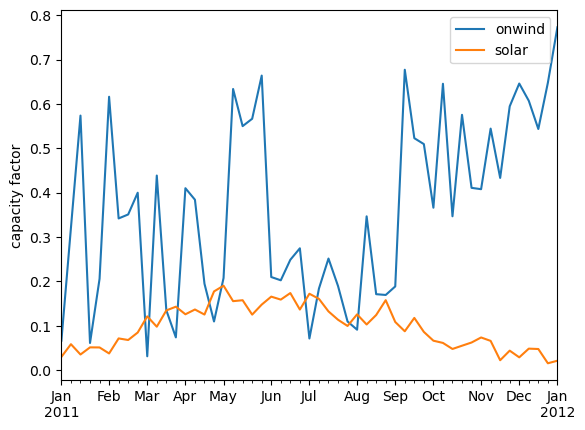

In [225]:
timeseries.resample("W").mean().plot(ylabel="capacity factor")

**Task 6:** Go to [model.energy](https://model.energy) and retrieve the time series for another region of your choice. Recreate the analysis above and compare the results.

:::{note}
Look for "Download Comma-Separated-Variable (CSV) file of data" in Step 2.
:::

<Axes: ylabel='capacity factor'>

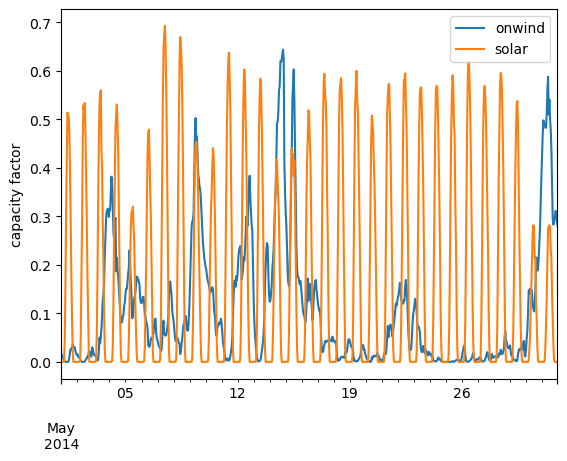

In [234]:
#Data from Bulgaria in 2014
bulgaria = pd.read_csv("bulgaria.csv", index_col=0, parse_dates=True)
bulgaria.mean()
'''Mean solar capacity factor in Bulgaria is 1.5x that of Ireland. However, it's onshore wind capacity factor 
is half of that of Ireland.'''
bulgaria.corr()
'''Correlations between solar and wind present a similar trend to that of Ireland, though even more complementary.'''
bulgaria.loc["05-2014"].plot(ylabel="capacity factor")
# bulgaria.resample("W").mean().plot(ylabel="capacity factor")